In [1]:
"""
LSTM Flood Forecasting Model (PyTorch)
Predicts streamflow 24 hours (1 day) in advance using historical weather and streamflow data.
Target: streamflow_cfs_target_24h

Downloads preprocessed data from the W&B artifact produced by missouri_preprocessing.py
"""
import torch
import polars as pl
import wandb
import numpy as np
import joblib
from SRC.helper_functions.preprocessing import processor

config = {
    "input_cols": [
        "latitude",
        "longitude",
        "streamflow_cfs_mean",
        "gage_height_ft_mean",
        "precipitation_mm",
        "temperature_c",
        "gage_height_ft_max",
        "gage_height_ft_min",
    ], 
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "start_date": "2010-01-01",
    "end_date": "2025-12-31",
    "file_path": "flood-dataset-missouri",
    "file_name": "flood_model_missouri",
    "table": "wandb.flood_model",
    "lag_window": 7,
    "frequency": "daily",
    "split_time_days": 30,
    "site_scaling" : False,
    "sites":["06926510",
                "06821250",
                "06927000",
                "06934000",
                "06910450",
                "06893500",
                "06893000"]
}

pcr = processor(config)
pcr.pull_duckdb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

shape: (7,)
Series: 'site_id' [str]
[
	"06910450"
	"06934000"
	"06821250"
	"06927000"
	"06893000"
	"06926510"
	"06893500"
]
(32399, 51)


In [2]:

def align_sites_by_date(X: pl.DataFrame, y: pl.DataFrame) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Keep only dates present in ALL sites.

    If site A has dates [1,2,3] and site B has [2,3,4],
    both are filtered to [2,3] so every site has identical timesteps.
    """
    sites = X["site_id"].unique().to_list()
    common_dates = None
    for site in sites:
        site_dates = set(
            X.filter(pl.col("site_id") == site)["observation_hour"].to_list()
        )
        common_dates = site_dates if common_dates is None else common_dates & site_dates

    before = len(X)
    mask = X["observation_hour"].is_in(list(common_dates))
    X_aligned = X.filter(mask)
    y_aligned = y.filter(mask)

    dropped = before - len(X_aligned)
    if dropped:
        print(f"  Dropped {dropped} rows ({dropped/before:.1%}) to align sites — {len(common_dates)} common dates retained")
    else:
        print(f"  All {len(common_dates)} dates already aligned across {len(sites)} sites")

    return X_aligned, y_aligned

print("Aligning train split...")
train_X, train_y = align_sites_by_date(train_X, train_y)
print("Aligning val split...")
val_X, val_y = align_sites_by_date(val_X, val_y)
print("Aligning test split...")
test_X, test_y = align_sites_by_date(test_X, test_y)


Aligning train split...
  Dropped 12440 rows (49.4%) to align sites — 1818 common dates retained
Aligning val split...
  Dropped 1601 rows (51.0%) to align sites — 220 common dates retained
Aligning test split...
  Dropped 1511 rows (48.0%) to align sites — 234 common dates retained


In [3]:

WINDOW_SIZE = 3

def create_sequences(X, y, site_ids, window_size):
    """Create sliding window sequences for all sites in parallel.

    Assumes all sites share the same dates (equal number of timesteps).
    Reshapes data to (num_sites, timesteps, features) and applies
    vectorized sliding window indexing — no Python loops over sites.

    Returns:
        X_seq: list of numpy arrays, one per site, each (num_windows, window_size, num_features)
        y_seq: list of numpy arrays, one per site, each (num_windows,)
    """
    unique_sites, inverse = np.unique(site_ids, return_inverse=True)
    num_sites = len(unique_sites)
    num_features = X.shape[1]

    # Sort by site so rows are grouped per site
    sort_idx = np.argsort(inverse)
    X_sorted = X[sort_idx]
    y_sorted = y[sort_idx]

    # Verify every site has the same number of timesteps
    _, counts = np.unique(site_ids[sort_idx], return_counts=True)
    timesteps = counts[0]
    assert np.all(counts == timesteps), (
        f"Sites have different timestep counts: {np.unique(counts)}"
    )

    # Reshape to (num_sites, timesteps, features)
    X_3d = X_sorted.reshape(num_sites, timesteps, num_features)
    y_2d = y_sorted.reshape(num_sites, timesteps)

    num_windows = timesteps - window_size
    if num_windows <= 0:
        return [], []

    # Vectorised sliding-window indices: (num_windows, window_size)
    win_idx = np.arange(window_size)[None, :] + np.arange(num_windows)[:, None]

    # Gather windows for every site at once
    # -> (num_sites, num_windows, window_size, num_features)
    X_seq = X_3d[:, win_idx]

    # Target = value at the last timestep of each window
    y_idx = np.arange(window_size - 1, window_size - 1 + num_windows)
    y_seq = y_2d[:, y_idx]

    # Return as list of per-site numpy arrays: [site1, site2, ...]
    X_list = [X_seq[i] for i in range(num_sites)]
    y_list = [y_seq[i] for i in range(num_sites)]

    return X_list, y_list


In [4]:

train_sites = train_X["site_id"].to_numpy()
val_sites = val_X["site_id"].to_numpy()
test_sites = test_X["site_id"].to_numpy()

# Drop site_id and observation_hour columns
drop_cols = ["site_id", "observation_hour"]
train_X_arr = train_X.drop(drop_cols).to_numpy()
val_X_arr = val_X.drop(drop_cols).to_numpy()
test_X_arr = test_X.drop(drop_cols).to_numpy()
train_y_arr = train_y.to_numpy()
val_y_arr = val_y.to_numpy()
test_y_arr = test_y.to_numpy()

print("\nCreating sequences...")
X_train_list, y_train_list = create_sequences(train_X_arr, train_y_arr, train_sites, WINDOW_SIZE)
X_val_list, y_val_list = create_sequences(val_X_arr, val_y_arr, val_sites, WINDOW_SIZE)
X_test_list, y_test_list = create_sequences(test_X_arr, test_y_arr, test_sites, WINDOW_SIZE)

# Concatenate all sites' features along feature axis: (num_windows, window_size, num_features * num_sites)
X_train = np.concatenate(X_train_list, axis=2)
X_val = np.concatenate(X_val_list, axis=2)
X_test = np.concatenate(X_test_list, axis=2)

# Stack targets as columns: (num_windows, num_sites)
y_train = np.column_stack(y_train_list)
y_val = np.column_stack(y_val_list)
y_test = np.column_stack(y_test_list)

# Drop rows with any NaN in X or y
def drop_nan_rows(X, y):
    nan_x = np.isnan(X).any(axis=(1, 2))
    nan_y = np.isnan(y).any(axis=1)
    mask = ~(nan_x | nan_y)
    return X[mask], y[mask]

before = len(X_train)
X_train, y_train = drop_nan_rows(X_train, y_train)
X_val, y_val = drop_nan_rows(X_val, y_val)
X_test, y_test = drop_nan_rows(X_test, y_test)
print(f"Dropped {before - len(X_train)} NaN rows from train")

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")



Creating sequences...
Dropped 72 NaN rows from train
X_train: (1743, 3, 308)  y_train: (1743, 7)
X_val:   (206, 3, 308)  y_val:   (206, 7)
X_test:  (225, 3, 308)  y_test:  (225, 7)


In [5]:
print(X_train[0].shape)

(3, 308)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [7]:
DROPOUT_RATE = 0.3

model = Sequential([
    GRU(32, return_sequences=True,),
    Dropout(DROPOUT_RATE),
    GRU(16, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(64),
    Dense(len(config["sites"]))])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.2741 - mae: 0.3354 - val_loss: 0.0779 - val_mae: 0.1705
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1273 - mae: 0.2251 - val_loss: 0.0588 - val_mae: 0.1432
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1035 - mae: 0.1998 - val_loss: 0.0563 - val_mae: 0.1338
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0865 - mae: 0.1803 - val_loss: 0.0549 - val_mae: 0.1298
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0716 - mae: 0.1597 - val_loss: 0.0557 - val_mae: 0.1303
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0647 - mae: 0.1472 - val_loss: 0.0554 - val_mae: 0.1280
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0607 - mae: 0.1379 - val_loss: 0.0518 - val_mae: 0.1184
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0570 - mae: 0.1305 - val_loss: 0.0488 - val_mae: 0.1193
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.05

In [12]:

pred_test = model.predict(X_test, verbose=0)

pred_test_real = pcr.target_scaler.inverse_transform(torch.tensor(pred_test)).numpy()
actual_test_real = pcr.target_scaler.inverse_transform(torch.tensor(y_test)).numpy()

for idx in range(len(config["sites"])):
    site = config["sites"][idx]
    print(f"\nSite {site}:")
    print(f"  {'Split':<8} {'Actual Mean':>14} {'Predicted Mean':>16} {'MAE':>10}")
    print(f"  {'-'*50}")
    for split, actual, pred in [
        ("Test",  actual_test_real[:, idx],  pred_test_real[:, idx]),
    ]:
        mae = np.abs(actual - pred).mean()
        print(f"  {split:<8} {actual.mean():>12.1f} CFS {pred.mean():>12.1f} CFS {mae:>8.1f} CFS")


Site 06926510:
  Split       Actual Mean   Predicted Mean        MAE
  --------------------------------------------------
  Test          54828.6 CFS      55182.8 CFS   6244.0 CFS

Site 06821250:
  Split       Actual Mean   Predicted Mean        MAE
  --------------------------------------------------
  Test          61322.1 CFS      61242.3 CFS   7062.9 CFS

Site 06927000:
  Split       Actual Mean   Predicted Mean        MAE
  --------------------------------------------------
  Test            313.4 CFS        303.7 CFS    396.5 CFS

Site 06934000:
  Split       Actual Mean   Predicted Mean        MAE
  --------------------------------------------------
  Test          73562.7 CFS      73780.6 CFS   8935.4 CFS

Site 06910450:
  Split       Actual Mean   Predicted Mean        MAE
  --------------------------------------------------
  Test          12829.0 CFS      12781.1 CFS   6477.0 CFS

Site 06893500:
  Split       Actual Mean   Predicted Mean        MAE
  -----------------------

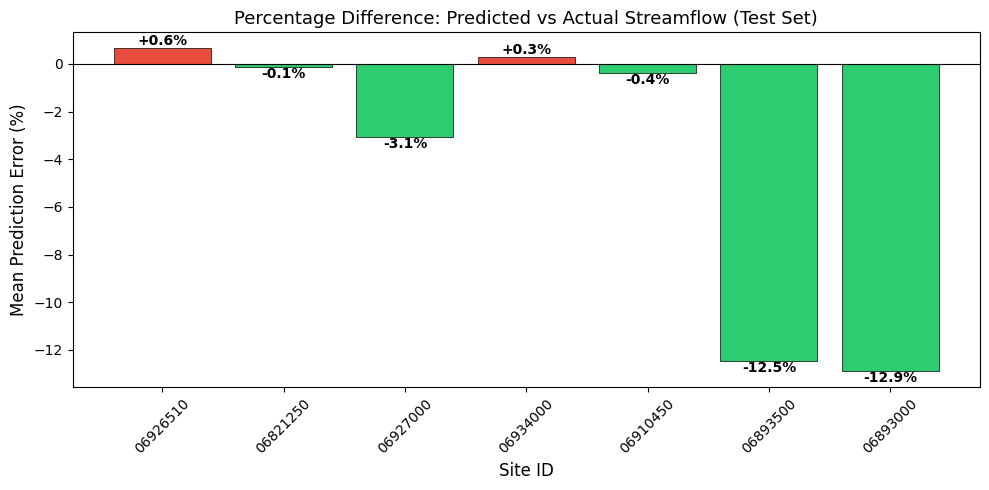

In [13]:
import matplotlib.pyplot as plt

sites = config["sites"]
num_sites = len(sites)

# Compute percentage difference: (pred - actual) / actual * 100
pct_diff_test = ((pred_test_real.mean(axis=0) - actual_test_real.mean(axis=0))
                 / actual_test_real.mean(axis=0) * 100)

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in pct_diff_test]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sites, pct_diff_test, color=colors, edgecolor='black', linewidth=0.5)

# Add percentage labels on each bar
for bar, pct in zip(bars, pct_diff_test):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{pct:+.1f}%', ha='center',
            va='bottom' if y >= 0 else 'top',
            fontweight='bold', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Site ID', fontsize=12)
ax.set_ylabel('Mean Prediction Error (%)', fontsize=12)
ax.set_title('Percentage Difference: Predicted vs Actual Streamflow (Test Set)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()